# $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss


- hamiltonian

$$
\begin{align}
    H&=\sum_{\mathbf{k}}[t_{\uparrow\uparrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\uparrow\downarrow}c_{\uparrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})+t_{\downarrow\uparrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\uparrow}(\mathbf{k})+t_{\downarrow\downarrow}c_{\downarrow}^\dagger(\mathbf{k})c_{\downarrow}(\mathbf{k})]-i\frac{\gamma}{2}\sum_{\mathbf{r}}n_\uparrow(\mathbf{r}) n_\downarrow(\mathbf{r}) \\
    &=\underbrace{\sum_{\mathbf{k}}\left[\varepsilon_1(\mathbf{k})c_1^\dagger(\mathbf{k})c_1(\mathbf{k}) + \varepsilon_2(\mathbf{k})c_2^\dagger(\mathbf{k})c_2(\mathbf{k})\right]}_{H_0} + \underbrace{\frac{-1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')}_{V_\text{loss}}
\end{align}

$$

$$t_{\uparrow\uparrow}=\frac{\hbar^2(k-q)^2}{2m_\mathrm{Yb}}+\frac{\delta}{2},\quad t_{\uparrow\downarrow}= t_{\downarrow\uparrow}=\frac{\Omega_R}{2},\quad t_{\downarrow\downarrow}=\frac{\hbar^2(k+q)^2}{2m_\mathrm{Yb}}-\frac{\delta}{2}$$

- number operators

$$n_\sigma = c_\sigma^\dagger(\mathbf{k})c_\sigma(\mathbf{k}), \quad \sigma=\uparrow,\downarrow$$
$$n_m = c_m^\dagger(\mathbf{k})c_m(\mathbf{k}), \quad m=1, 2$$

$$
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & \beta(\mathbf{k}) \\
    -\beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix},\quad
\begin{pmatrix}
    c_\uparrow(\mathbf{k}) \\ c_\downarrow(\mathbf{k})
\end{pmatrix}
=
\begin{pmatrix}
    \alpha(\mathbf{k}) & -\beta(\mathbf{k}) \\
    \beta(\mathbf{k}) & \alpha(\mathbf{k})
\end{pmatrix}
\begin{pmatrix}
    c_1(\mathbf{k}) \\ c_2(\mathbf{k})
\end{pmatrix}
$$
$\alpha$ and $\beta$ are real and $\alpha^2+\beta^2=1$


- fourier transforms

$$\begin{align}
	c_\sigma(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{k}),&\quad c_\sigma^\dagger(\mathbf{r})=\frac{1}{\sqrt{N}}\sum_{\mathbf{k}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{k})\\
	c_\sigma(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{-i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma(\mathbf{r}),&\quad c_\sigma^\dagger(\mathbf{k})=\frac{1}{\sqrt{N}}\sum_{\mathbf{r}}e^{i\mathbf{k}\cdot{\mathbf{r}}}c_\sigma^\dagger(\mathbf{r})
\end{align}$$

$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

Use matrix representation under this basis.

import dependencies

In [29]:
import os
import itertools
import functools


import jax

jax.config.update("jax_enable_x64", True)
from jax.extend.backend import get_backend

import jax.numpy as jnp
import numpy as np
import tqdm
import scipy

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import networkx as nx
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.animation import FFMpegWriter

from opalg import lattice
from opalg import sec_quant

from ybsoc import *

print(jax.devices())

print(f"JAX is using: {get_backend().platform}")

[CudaDevice(id=0)]
JAX is using: gpu


## Time evolution

In [30]:
system = YbSOCSystem(
    d=1,
    lengths=[10,],
    n_particle=4,
    hbar=1,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.1,
)
system.print_info()

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


## ED

In [31]:
def draw_ErEi_scatter(eigenvalues, eigenvectors, co, title, save_path = None):
    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    plt.figure(figsize=(6, 4.5))
    scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

    cbar = plt.colorbar(scatter)
    cbar.set_label('$\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

    plt.xlabel("E_r (Real part)")
    plt.ylabel("E_i (Imag part)")
    plt.title(title)

    # plt.grid(True)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.close()

In [32]:
system = YbSOCSystem(
    d=1,
    lengths=[10,],
    n_particle=4,
    hbar=1,
    q=0.03,
    m_Yb = 1,
    delta = 0.08,
    omega_R = 0.2,
    gamma = 0.1,
)
system.print_info()

4845 4-particle states
75.70 KB per state (complex128)
358.19 MB for dense representation of an operator (complex128)


In [33]:
H_dense = system.dense_hamiltonian()
eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)

E_r = jnp.real(eigenvalues)
E_i = jnp.imag(eigenvalues)

min_E_r_idx = jnp.argmin(E_r)
min_E_i_idx = jnp.argmin(E_i)

100%|██████████| 4845/4845 [00:00<00:00, 14603.16it/s]


In [34]:
corr_mat = system.cooper_pair_corr()
co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

/home/pco0511/.local/lib/python3.12/site-packages/jax/_src/array.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(self._value, dtype=dtype, **kwds)


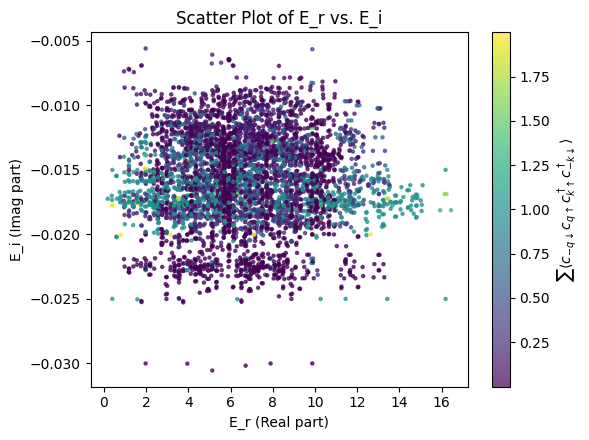

Array(0.03909159+0.j, dtype=complex128)

In [35]:

plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(E_r, E_i, c=co, alpha=0.7, s=5)

cbar = plt.colorbar(scatter)
cbar.set_label('$\\sum\\langle{c_{-q\\downarrow} c_{q\\uparrow}}c_{k\\uparrow}^\\dagger c_{-k\\downarrow}^\\dagger\\rangle$')

plt.xlabel("E_r (Real part)")
plt.ylabel("E_i (Imag part)")
plt.title("Scatter Plot of E_r vs. E_i")

# plt.grid(True)
plt.tight_layout()
plt.show()

co[min_E_i_idx]

#### $\chi$ vs $\gamma$

In [36]:
N = 51
corr_Er_min = np.empty((N,))
corr_Ei_min = np.empty((N,))
corr_Ei_max = np.empty((N,))

lengths = [8,]
n_particle = 4

gammas = np.linspace(0, 1, N)


for idx, gamma in enumerate(tqdm.tqdm(gammas)):
    system = YbSOCSystem(
        d=1,
        lengths=lengths,
        n_particle=n_particle,
        hbar=1,
        q=0.03,
        m_Yb = 1,
        delta = 0.08,
        omega_R = 0.06,
        gamma = gamma
    )
    H_dense = system.dense_hamiltonian(
        display_progress=False
    )
    eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)

    E_r = jnp.real(eigenvalues)
    E_i = jnp.imag(eigenvalues)

    min_E_r_idx = jnp.argmin(E_r)
    min_E_i_idx = jnp.argmin(E_i)
    max_E_i_idx = jnp.argmax(E_i)
    
    corr_mat = system.cooper_pair_corr()
    co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)
    
    corr_Er_min[idx] = co[min_E_r_idx].astype(jnp.float64)
    corr_Ei_min[idx] = co[min_E_i_idx].astype(jnp.float64)
    corr_Ei_max[idx] = co[max_E_i_idx].astype(jnp.float64)


100%|██████████| 51/51 [03:18<00:00,  3.90s/it]


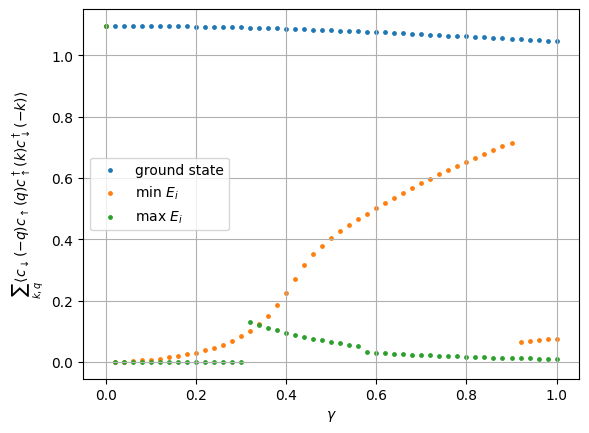

In [37]:
plt.figure()
plt.scatter(gammas, corr_Er_min, label=f"ground state", s=6)
plt.scatter(gammas, corr_Ei_min, label=f"min $E_i$", s=6)
plt.scatter(gammas, corr_Ei_max, label=f"max $E_i$", s=6)
plt.xlabel("$\\gamma$")
plt.ylabel("$\\sum_{k, q}\\langle c_{\\downarrow}(-q)c_{\\uparrow}(q)c_{\\uparrow}^\\dagger(k)c_{\\downarrow}^\\dagger(-k)\\rangle$")
plt.legend()
plt.grid()
plt.show()

#### diagonalize & save

In [38]:
sim_name = "sim6"

In [39]:
N = 51
corr_Er_min = np.empty((7, N))
corr_Ei_min = np.empty((7, N))
corr_Ei_max = np.empty((7, N))

gammas = np.linspace(0, 0.5, N)
lengths = [8,]

data_root = f"/home/pco0511/yb-soc-two-body-loss/data/{sim_name}"
os.makedirs(data_root, exist_ok=True)

n_particle_range = range(1, 5)

for n_particle in n_particle_range:
    subdir = os.path.join(data_root, f"dim8_npar{n_particle}_gamma-linsp0-0.5-51")
    os.makedirs(subdir, exist_ok=True)
    for idx, gamma in enumerate(tqdm.tqdm(gammas)):
        system = YbSOCSystem(
            d=1,
            lengths=lengths,
            n_particle=n_particle,
            hbar=1,
            q=0.03,
            m_Yb = 1,
            delta = 0.08,
            omega_R = 0.06,
            gamma = gamma
        )
        H_dense = system.dense_hamiltonian(
            display_progress=False
        )
        eigenvalues, eigenvectors = jnp.linalg.eig(H_dense)
        
        np.save(
            os.path.join(subdir, f"eigenvalues_{idx}.npy"),
            eigenvalues
        )
        np.save(
            os.path.join(subdir, f"eigenvectors_{idx}.npy"),
            eigenvectors
        )

        E_r = jnp.real(eigenvalues)
        E_i = jnp.imag(eigenvalues)

        min_E_r_idx = jnp.argmin(E_r)
        min_E_i_idx = jnp.argmin(E_i)
        max_E_i_idx = jnp.argmax(E_i)

        corr_mat = system.cooper_pair_corr()
        corr = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

        corr_Er_min[n_particle-n_particle_range[0], idx] = corr[min_E_r_idx].astype(jnp.float64)
        corr_Ei_min[n_particle-n_particle_range[0], idx] = corr[min_E_i_idx].astype(jnp.float64)
        corr_Ei_max[n_particle-n_particle_range[0], idx] = corr[max_E_i_idx].astype(jnp.float64)



100%|██████████| 51/51 [03:19<00:00,  3.91s/it]


In [40]:
data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"
np.save("/home/pco0511/yb-soc-two-body-loss/data/sim2/gamma.npy", gammas)
np.save(os.path.join(data_root, "minEr.npy"), corr_Er_min)
np.save(os.path.join(data_root, "minEi.npy"), corr_Ei_min)

#### load data

In [ ]:
N = 51
corr_Er_min = np.empty((7, N))
corr_Ei_min = np.empty((7, N))

data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"

gammas = np.load(os.path.join(data_root, "gamma.npy"))
lengths = [8,]

for n_particle in range(1, 7):
    subdir = os.path.join(data_root, f"dim8_npar{n_particle}_gamma-linsp0-0.5-51")
    os.makedirs(subdir, exist_ok=True)
    figdir = os.path.join(subdir, f"figures")
    os.makedirs(figdir, exist_ok=True)
    for idx, gamma in tqdm.tqdm(enumerate(gammas)):
        eigenvalues = np.load(os.path.join(subdir, f"eigenvalues_{idx}.npy"))
        eigenvectors = np.load(os.path.join(subdir, f"eigenvectors_{idx}.npy"))

        corr_mat = cooper_pair_corr(lengths, n_particle)
        co = jnp.real(jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors))

        # draw_ErEi_scatter(
        #     eigenvalues, 
        #     eigenvectors, 
        #     co,
        #     f"$\\gamma={gamma:.2f}$",
        #     os.path.join(figdir, f"{idx}.png")
        # )

        E_r = jnp.real(eigenvalues)
        E_i = jnp.imag(eigenvalues)

        # min_E_r_idx = jnp.argmin(E_r)
        # min_E_i_idx = jnp.argmin(E_i)

        max_E_r_idx = jnp.argmax(E_r)
        max_E_i_idx = jnp.argmax(E_i)


        corr = cooper_pair_corr_diag(lengths, n_particle)
        probs = jnp.abs(eigenvectors) ** 2
        co = jnp.einsum('i,ij->j', corr, probs)

        # corr_mat = (lengths, n_particle)
        # co = jnp.einsum('ji,jk,ki->i', eigenvectors.conj(), corr_mat, eigenvectors)

        corr_Er_min[n_particle-1, idx] = co[max_E_r_idx].astype(jnp.float64)
        corr_Ei_min[n_particle-1, idx] = co[max_E_i_idx].astype(jnp.float64)

0it [00:00, ?it/s]


NameError: name 'cooper_pair_corr' is not defined

In [ ]:
data_root = f"/home/pco0511/yb-soc-two-body-loss/data/sim{sim_num}"

gammas = np.load(os.path.join(data_root, "gamma.npy"))
corr_Er_min = np.load(os.path.join(data_root, "minEr.npy"))
corr_Ei_min = np.load(os.path.join(data_root, "minEi.npy"))

FileNotFoundError: [Errno 2] No such file or directory: '/home/pco0511/yb-soc-two-body-loss/data/sim5/gamma.npy'

In [ ]:
corr_Ei_min

array([[7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        , 7.        , 7.        , 7.        , 7.        ,
        7.        ],
       [6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.        , 6.        , 6.        , 6.        ,
        6.        , 6.     

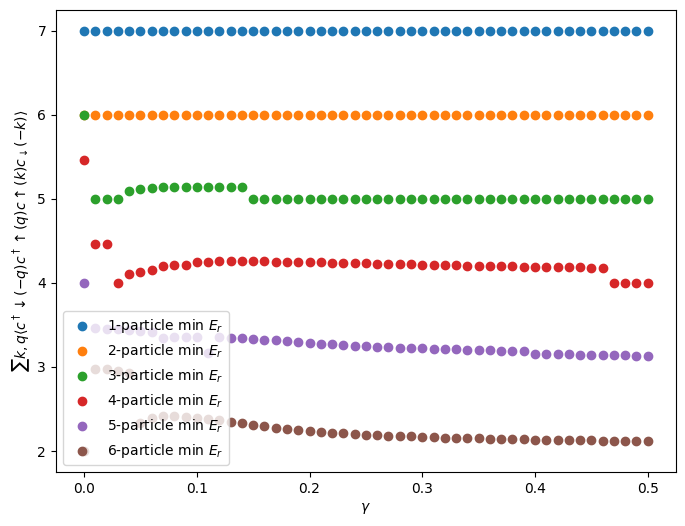

In [ ]:
plt.figure(figsize=(8, 6))
for i in range(1, 7):
    # plt.scatter(gammas, corr_Er_min[i - 1], label=f"{i}-particle ground state")
    plt.scatter(gammas, corr_Ei_min[i - 1], label=f"{i}-particle min $E_r$")

plt.xlabel("$\\gamma$")
plt.ylabel("$\\sum{k, q}\\langle c^\\dagger{\\downarrow}(-q)c^\\dagger{\\uparrow}(q)c{\\uparrow}(k)c_{\\downarrow}(-k)\\rangle$")
plt.legend()
plt.show()

In [ ]:
gammas

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 ])

$$\sum_{k, q}\langle c^\dagger_{\downarrow}(-q)c^\dagger_{\uparrow}(q)c_{\uparrow}(k)c_{\downarrow}(-k)\rangle$$